<a href="https://colab.research.google.com/github/aurelianmoge/CE-4110-UVa-personal-work/blob/main/Homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2: Nonlinear Programming and Evolutionary Algorithms

### In 2010, Prof. Quinn's husband, Alex Looi, conducted an experiment to model predator-prey dynamics in a chemostat (bioreactor) under different salinities. Each day, he measured the concentration of chlorella (a type of algae) and counted the number of rotifers (type of plankton that eats chlorella) in the chemostat. He modeled the chlorella and rotifer populations by the Fussman model of predator-prey dynamics (Fussman et al., 2000), represented by the following system of differential equations:
\begin{align}
    \frac{dN}{dt} = \delta (N_0 - N) - \frac{B_C N}{K_C + N} C \tag{1}\\
    \frac{dC}{dt} = \frac{B_C N}{K_C + N} C - \frac{B_R C}{K_R + C} \Big(\frac{R}{e}\Big) - \delta C \tag{2}\\
    \frac{dR}{dt} = \frac{B_R C}{K_R + C}R - (\delta + m)R \tag{3}
\end{align}
### where $C$, $R$, and $N$ are the quantities of chlorella, rotifers and nitrogen; $K_C$ and $K_R$ are the half-saturation constants of chlorella and rotifers; $B_C$ and $B_R$ are the growth rate of chlorella and rotifers; $e$ is the assimilation efficiency of the predator; $m$ is the mortality rate of the predator; and $\delta$ is the flow rate in the chemostat. He hypothesized that the half-saturation constant of the rotifers in this system, $K_R$, would be affected by salinity. Let's test his hypothesis! Attached is the data he collected, after being smoothed by exponential smoothing.

### Fussmann, G. F., Ellner, S. P., Shertzer, K. W., \& Hairston Jr, N. G. (2000). Crossing the Hopf bifurcation in a live predator-prey system. *Science*, *290*(5495), 1358-1360.

### 1. Compute the Hessians of the first and third equations and use the Hessians to explain why these two equations are not convex. (Don't worry about the second equation because it has three variables, making it more complicated!) Show your derivations by hand. (30 pts)
### **Hint: Recall the quotient rule**:
\begin{align}
        h(x) &= \frac{f(x)}{g(x)} \tag{4}\\
        h'(x) &= \frac{f'(x)g(x)-g'(x)f(x)}{[g(x)]^2} \tag{5}
\end{align}

$\color{red}{\text{Upload/transcribe your derivation here or upload as separate document.}}$

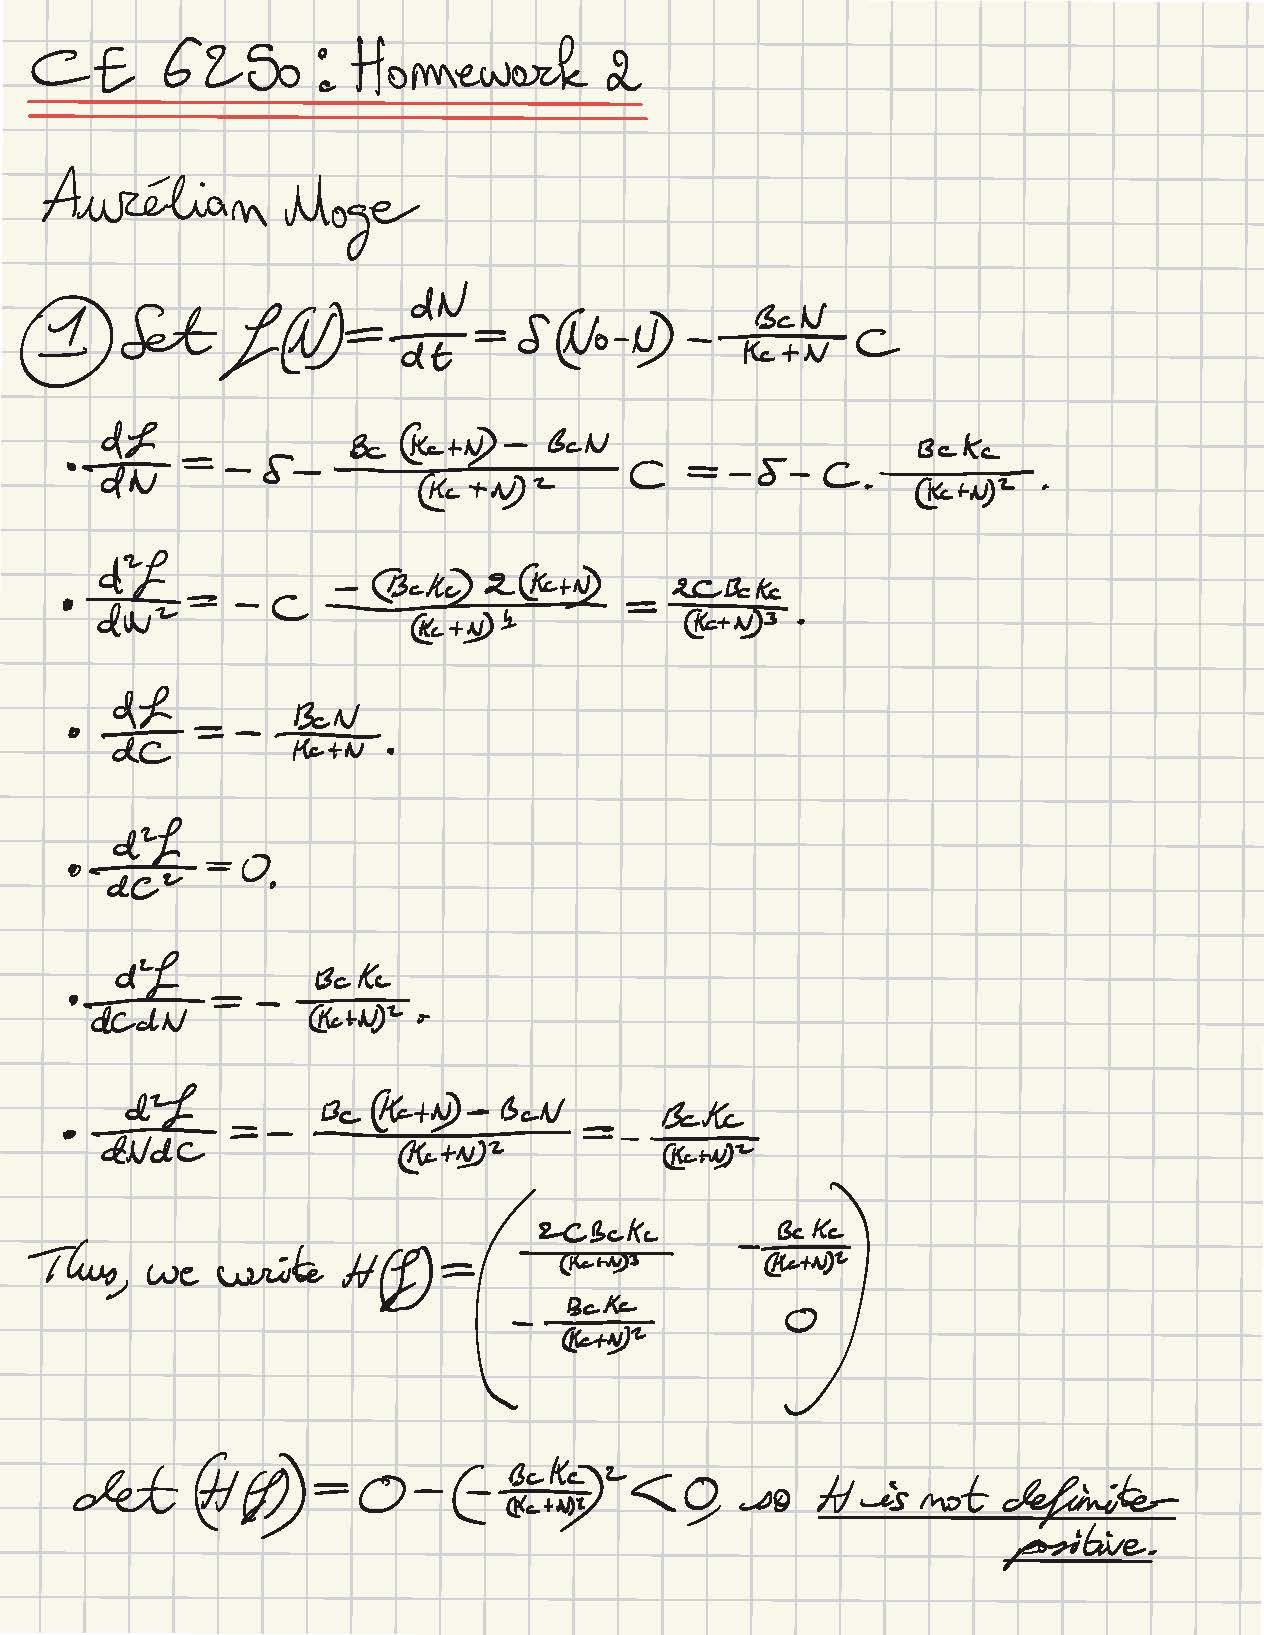


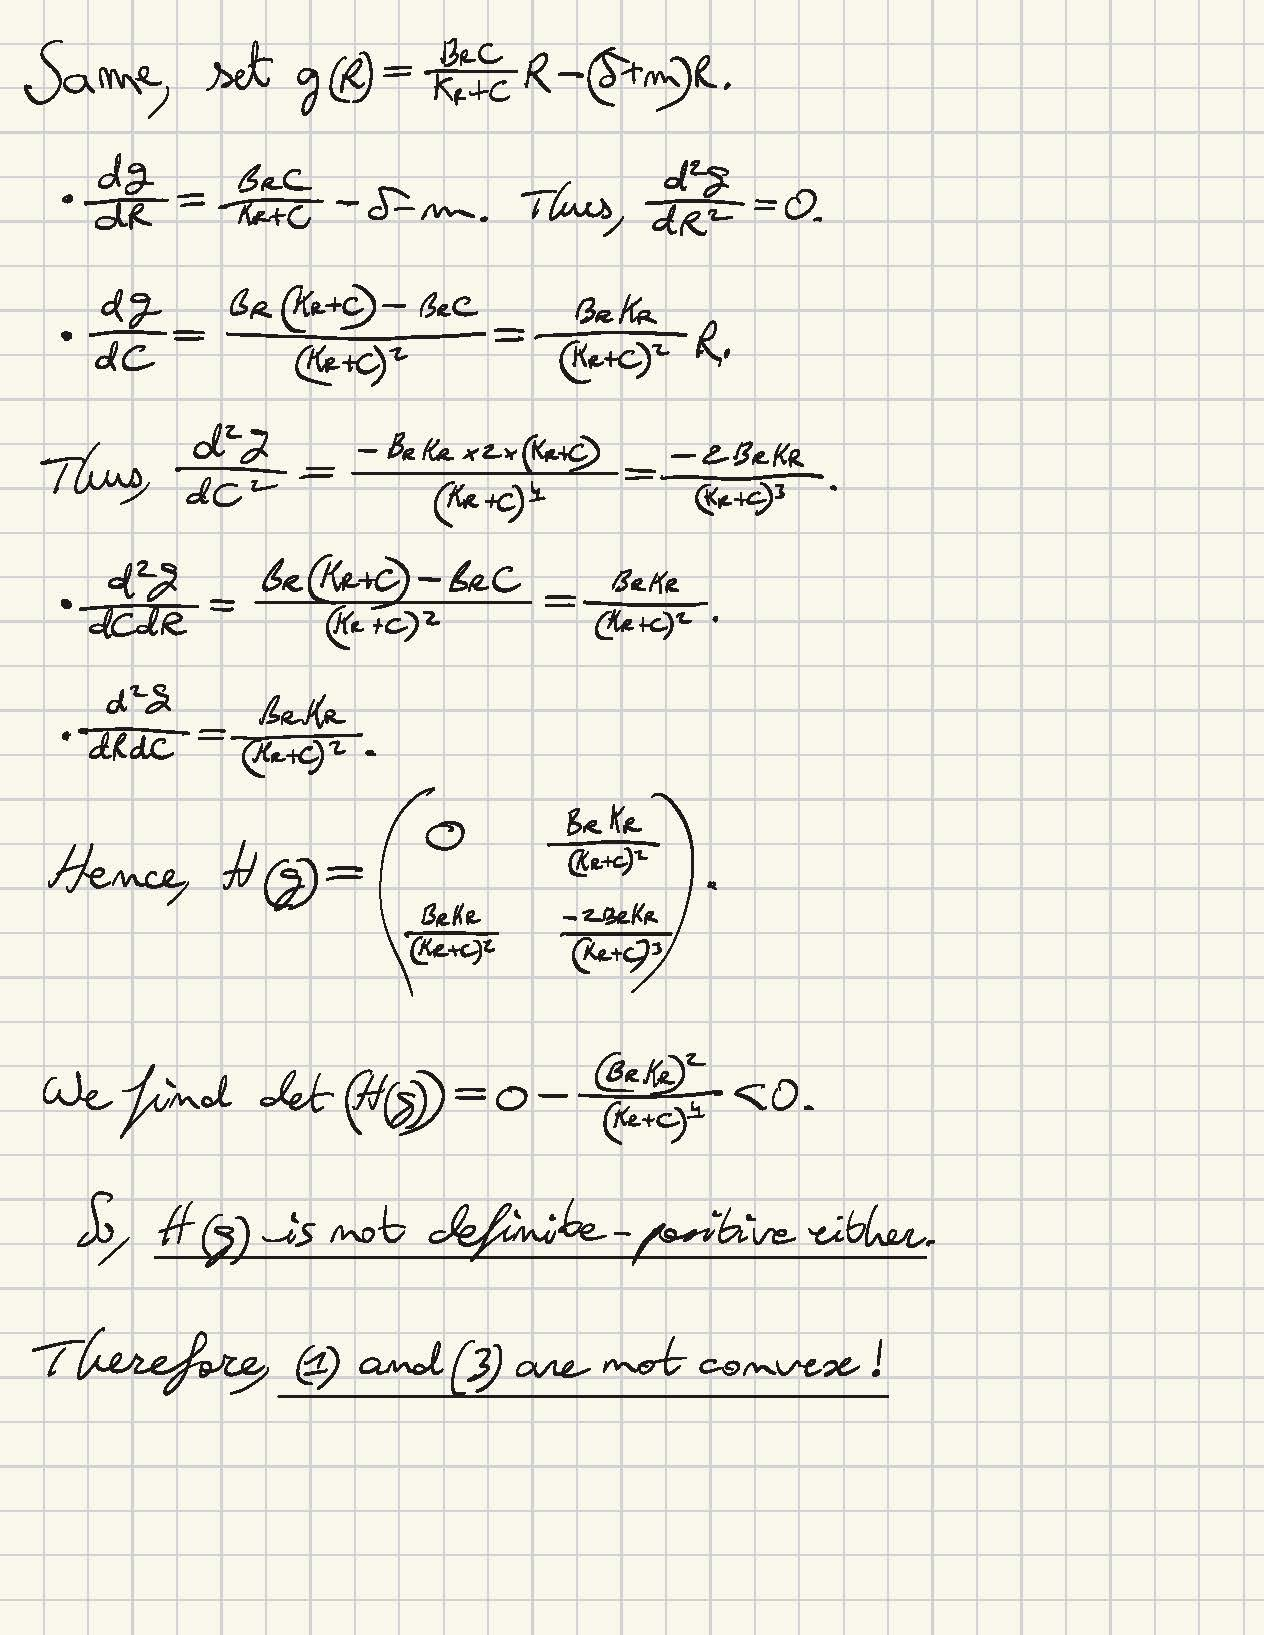

### 2. Using the Fussmann function below, simulate n=38 time steps of this model assuming the parameters and initial values provided in Table 1. Plot the Chlorella and Rotifer populations in solid black and red, respectively, on one plot with a shared ("twin") axis but different y axis. (10 pts)

Table 1: Example Inputs  

| Parameter | $K_C$ | $K_R$ | $B_C$ | $B_R$ | $e$  | $m$ | $\delta$ | $N_0$ | $C_0$ | $R_0$ |
| --------- | ----- | ---- | ----- | ----- | ---- | --- | -------- | ----- | ----- | ----- |
| Value     | 4.3   | 15.0 | 3.3   | 1.0   | 0.25 | 0.3 | 0.4      | 80    | 2.5     | 0.7  |

$\color{red}{\text{The code below is complete. It simulates a system of ordinary differential equations representing the Fussman model}}$

In [ ]:
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss
from scipy.optimize import differential_evolution, minimize

N0 = 80 # initial nitrogen mass
C0 = 2.5 # initial chlorella population
R0 = 0.7 # intiial rotifer population
delta = 0.4 # dilution rate

y0 = [N0, C0, R0] # initial state variables
time = np.arange(0, 38) # number of time steps

def Fussmann(y0, t, params):
    """
    The predator-prey ode with Juveniles

    Parameters:
    _______________________________________________________
    betaC: params[0]  # Offspring production: Chlorella
    Kc:    params[1]  # Half Saturation constant of Chlorella
    e:     params[2]  # Assimilation efficiency of rotifers
    m:     params[3]  # Death rate of Rotifers
    betaR: params[4]  # Offspring production of Rotifers
    Kr:    params[5]  # Half saturation constant for R

    Populations:
    _______________________________________________________
    dN: Concentration of Nitrogen
    dC: Concentration of Chlorella
    dR: Concentration of Rotifers
    """
    ## Parameters
    # Whole system parameters
    #d = parms[0]

    # Chlorella parameters
    K_C = params[0] # Half Saturation constant for Chlorella
    K_R = params[1] # Half saturation constant for Rotifers
    B_C = params[2] # Growth rate of Chlorella
    B_R = params[3] # Growth rate of Rotifers
    e = params[4] # Assimilation rate of Rotifers
    m = params[5] # Death rate of Rotifers

    ##initial conditions
    N = y0[0]
    C = y0[1]
    R = y0[2]

    ##Differential equations
    dN = delta*(N0 - N) - (B_C*N)/(K_C + N)*C # rate of change in nitrogen
    dC = (B_C*N)/(K_C + N)*C - ((B_R*C) / (K_R + C)*R/e) - delta*C # rate of change in chlorella population
    dR = (B_R*C)/(K_R + C)*R - (delta + m) * R # rate of change of rotifer population

    return [dN, dC, dR]

$\color{red}{\text{Run simulation with default parameters and plot resulting time series below.}}$

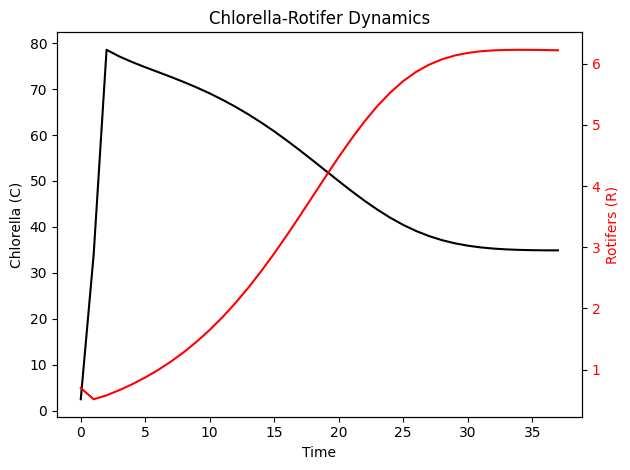

In [ ]:
# run simulation and make plot here
#----------------------------------

# Set the parameters
params = [4.3, 15.0, 3.3, 1.0, 0.25, 0.3]

# Solve the ODE system using the odeint function from scipy.integrate
solution = integrate.odeint(Fussmann, y0, time, args=(params,))

# Extract variables from the solution
N = solution[:, 0]
C = solution[:, 1]
R = solution[:, 2]

# Create two vertically stacked panels sharing the x-axis
fig, ax1 = plt.subplots()

# Chlorella panel
ax1.plot(time, C, c="black")
ax1.set_xlabel('Time')
ax1.set_ylabel('Chlorella (C)')
ax1.tick_params(axis='y')

# Rotifer panel
ax2 = ax1.twinx()
ax2.plot(time, R, c="red", label="Rotifers")
ax2.set_ylabel("Rotifers (R)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

ax1.set_title("Chlorella-Rotifer Dynamics")

plt.tight_layout()
plt.show()

### b. Now let's use this model to fit Alex's data, which is a time series of 38 time steps. The values of N0, C0, R0 and $\delta$ were measured in the lab and are the same as those listed in Table 1. The other 6 parameters need to be estimated from the data. Generate a Latin hypercube of 50 samples of these 6 parameters over their bounds, provided in Table 2 (set the seed to make it reproducible). Use these to initialize the population of a search with Differential Evolution for the set of parameters that maximizes the average NSE of simulated and observed chlorella and rotifer populations under each salinity (again, set the seed to make it reproducible). Report the average NSE and parameter estimates of each fit. Note that the Algae columns correspond to Chlorella populations. Hint: You will need to update your Fussmann function to take observed C and R values as an argument and return the negative of the average NSE when those arguments are passed. (20 pts)

Table 2: Parameter Ranges  

| Parameter   | Lower Bound | Upper Bound |
| ----------- | ----------- | ----------- |
| $ K_C $     | 1.0         | 25.0        |
| $ K_R $     | 1.0         | 50.0        |
| $ B_C $     | 1.0         | 10.0        |
| $ B_R $     | 0.1         | 10.0        |
| $ e $       | 0.01        | 0.50        |
| $ m $       | 0.0         | 0.9         |

$\color{red}{\text{The code below is complete. It reads in the data and then organizes it into a dictionary, dic_dfs,}}$  
$\color{red}{\text{where each salinity has a data frame of rotifer and chlorella populations associated with it.}}$

In [ ]:
# read in experimental data
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
data = pd.read_csv("drive/MyDrive/CE-6250/ExpData.csv")

# create dictionaries with the key being the salinity and the value being the associated observed dataset
salinities = []

for colname in data.columns:
    salinity = colname.split(".")[-1]
    if salinity not in salinities:
        salinities.append(salinity)

dic_dfs = {}
for salinity in salinities:
    for colname in data.columns:
        if colname.split(".")[-1] == salinity:
            if colname.split(".")[0].split(" ")[-1] == "Rotifers":
                S_R = data[colname]
                S_R.name = "R"
            if colname.split(".")[0].split(" ")[-1] == "Algae":
                S_C = data[colname]
                S_C.name = "C"
    dic_dfs[salinity] = pd.concat([S_R,S_C], axis = 1)
dic_dfs

Mounted at /content/drive


{'3':            R           C
 0   1.601544    2.279321
 1   0.918466    2.682872
 2   0.523395    3.830515
 3   0.444546    7.853645
 4   0.693212   17.042953
 5   1.271072   32.081756
 6   2.398660   50.206668
 7   4.109004   64.227486
 8   6.487622   56.082956
 9   8.705628   30.198051
 10  9.412891    8.774474
 11  8.469051   -0.146444
 12  6.170896   -1.311569
 13  3.725722   -0.011590
 14  2.064962    1.562006
 15  1.245003    3.447101
 16  1.038647    6.746106
 17  1.191662   13.118507
 18  1.584543   23.154539
 19  2.030264   36.360770
 20  2.536535   52.901554
 21  3.228269   72.368672
 22  3.600482   90.259022
 23  3.446207   99.210725
 24  3.179634  101.927336
 25  3.210101  103.809861
 26  3.471853  105.808330
 27  3.559012  105.468220
 28  3.530607  100.748633
 29  3.647057   91.414280
 30  4.197914   78.210027
 31  5.090517   61.235098
 32  6.029186   46.965549
 33  6.885814   34.821909
 34  7.701714   20.593401
 35  7.627521    4.516909
 36  6.157616    2.279321
 37  4.

$\color{red}{\text{Complete the function below to calculate the objective function: average NSE of chlorella and rotifer populations. Negate to minimize.}}$

In [ ]:
def ObjFunc(params, y0, t, data):
    """
    The Fitness Function: the average of Rotifer NSE and Chlorella NSE.
    """

    # Run the Fussman model with the current parameters
    solution = integrate.odeint(Fussmann, y0, t, args=(params,))

    # Extract simulated Chlorella and Rotifer
    C_sim = solution[:, 1]
    R_sim = solution[:, 2]

    # Extract observed Chlorella and Rotifer
    C_obs = data["C"].values
    R_obs = data["R"].values


    ## compute objective function

    #compute Rotifer NSE
    NSE_rot = 1 - np.sum((R_sim-R_obs)**2)/np.sum((R_obs - np.mean(R_obs))**2)

    #compute Chlorella NSE
    NSE_chlo = 1 - np.sum((C_sim-C_obs)**2)/np.sum((C_obs - np.mean(C_obs))**2)

    #compute the average of Rotifer NSE and Chlorella NSE (negate to minimize)
    ObjFunc = - (NSE_rot + NSE_chlo)/2

    return ObjFunc

In [ ]:
# Remark: we do not use of the log-NSE as some observed variables are negative
for salinity, df in dic_dfs.items():
    print("Salinity:", salinity)
    print("C min:", df["C"].min())
    print("R min:", df["R"].min())
    print("NaN:", df.isna().sum())
    print()

Salinity: 3
C min: -1.31156926
R min: 0.444546274
NaN: R    0
C    0
dtype: int64

Salinity: 16
C min: -0.070623124
R min: -0.056607011
NaN: R    0
C    0
dtype: int64

Salinity: 35
C min: -0.811854083
R min: 0.13394803
NaN: R    0
C    0
dtype: int64

Salinity: 45
C min: 3.021241951
R min: 0.117125706
NaN: R    0
C    0
dtype: int64



$\color{red}{\text{Complete the code below to calibrate with DE}}$

In [ ]:
# specify parameter bounds
bounds = [(1, 25), (1, 50), (1, 10), (0.1, 10), (0.01, 0.5), (0, 0.9)]

# generate initial population of 50 from Latin hypercube sample with seed=1
sampler = ss.qmc.LatinHypercube(d=6, seed=1)
sample = sampler.random(n=50)
l_bounds = np.array(bounds)[:,0]
u_bounds = np.array(bounds)[:,1]
x0 = ss.qmc.scale(sample, l_bounds, u_bounds)

# initialize data frame of 0s that will later store results
DE_results = pd.DataFrame(columns=["K_C","K_R","B_C","B_R","e","m","NSE"],index=salinities,data=0.0)

# loop through salinities and optimize parameters with DE
for salinity in dic_dfs.keys():
    df_obs = dic_dfs[salinity] # data of chlorella and rotifer populations at this salinity
    # use DE to optimize ObjFunc
    result = differential_evolution(ObjFunc, bounds=bounds, args=(y0, time, df_obs), init=x0, seed=1, maxiter=1000)

    # fill data frame with parameter values and objective value
    DE_results.iloc[np.where(DE_results.index == salinity),0:len(bounds)] = result.x # parameter values
    DE_results["NSE"].iloc[np.where(DE_results.index == salinity)] = - result.fun # objective value

DE_results

/tmp/ipykernel_584/1197465388.py:7: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solution = integrate.odeint(Fussmann, y0, t, args=(params,))
/tmp/ipykernel_584/2776829676.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-

,K_C,K_R,B_C,B_R,e,m,NSE
3,25.000000,50.000000,1.943269,3.493998,0.451210,0.900000,0.174693
16,11.078770,5.321053,1.754659,1.475375,0.118861,0.058645,0.636007
35,15.665345,8.265667,2.016885,1.209901,0.251937,0.266443,0.680559
45,1.132502,4.477189,1.000000,1.507670,0.500000,0.871635,0.697871


The best NSE is reached for a salinity = 45. At this stage, the adjustment of the simulation to the observation is quite good, with a NSE = 0.698. For salinities of 16 and 35, the NSE is slightly lower but still acceptable (0.64 and 0.68). However, for the salinity=3, the NSE is very low (0.17).

One can also remark that K_R is indeed affected by salinity, as it is continuously decreasing here.

### c. Generate another Latin hypercube with 10 samples to serve as initial estimates to scipy.optimize.minimize with the default solver (BFGS). Again, set the seed to 1 to make it reproducible. Use this solver to find a set of parameters that maximizes the average NSE of simulated and observed chlorella and rotifer populations under each salinity. Report the NSEs and parameter estimates in a pandas dataframe in which each row corresponds to a salinity and each column corresponds to NSE or a parameter. (20 pts)

$\color{red}{\text{Complete the code below to calibrate with BFGS}}$

In [ ]:
# initialize data frame of 0s that will later store results
BFGS_results = pd.DataFrame(columns=["K_C","K_R","B_C","B_R","e","m","NSE"],index=salinities,data=0.0)

# loop through salinities and optimize parameters with BFGS
for salinity in dic_dfs.keys():
    df_obs = dic_dfs[salinity] # data of chlorella and rotifer populations at this salinity
    bestObj = np.inf # initialize the best objective value so far for this salinity at infinity
    # loop through initial starting points and update bestObj value and corresponding result if it improved
    for x_start in x0:
      # We use of L-BFGS-B (in adequation with the scipy documentation) as the problem has bounds
        result = minimize(ObjFunc, x0=x_start, args=(y0, time, df_obs), method="L-BFGS-B", bounds=bounds)
        if result.fun < bestObj:
            bestObj = result.fun
            bestResult = result

    # fill data frame with parameter values and objective value
    # we switch from iloc to loc as pandas prints a warning
    BFGS_results.loc[salinity, ["K_C", "K_R", "B_C", "B_R", "e", "m"]] = bestResult.x
    # parameter values
    BFGS_results.loc[salinity, "NSE"] = -bestResult.fun

BFGS_results

/tmp/ipykernel_584/1197465388.py:7: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solution = integrate.odeint(Fussmann, y0, t, args=(params,))
/tmp/ipykernel_584/1197465388.py:7: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solution = integrate.odeint(Fussmann, y0, t, args=(params,))
/tmp/ipykernel_584/1197465388.py:7: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solution = integrate.odeint(Fussmann, y0, t, args=(params,))
/tmp/ipykernel_584/1197465388.py:7: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solution = integrate.odeint(Fussmann, y0, t, args=(params,))


,K_C,K_R,B_C,B_R,e,m,NSE
3,6.073513,3.960126,3.332020,0.896350,0.190902,0.151707,0.598342
16,21.619141,2.013150,1.996394,0.743201,0.099353,0.016755,0.685095
35,1.000000,10.442597,1.605052,1.246535,0.203574,0.241871,0.685447
45,1.010048,2.028499,1.000000,1.465384,0.481272,0.900000,0.700824


### $\color{red}{\text{Which algorithm achieves better NSE values, and what does that suggest?}}$

As for the DE algorithm, the best NSE is reached for salinity=45.
The approximate size of the NSE is the same for both DE and BFGS algorithms as far as salinities of 16, 35, and 45 are considered. If there is a slight difference, it is even the BFGS result that is slightly larger. In addition, the NSE is significantly improved for the salinity of 3 with the BFGS algorithm (0.598 compared to 0.175).

Therefore, the DE algorithm achieves better NSE values, but the gap is reduced as salinity increases.

It suggests that the problem becomes more stable with the increase in salinity. With a particulatly low value of salinity (e.g., salinity=3), the global method behind the DE algorithm seems less efficient than the local gradient-based method implemented by the BFGS algorithm.

As to the experimental problem, we can assume that the evolution in K_R according to salinity is closer to the BFGS representation than to the DE one. Thus, the relationship between K_R and salinity is probably not monotonic. As an example, one can notice that the half-saturation constant of the rotifers is estimated at a level of 2 for a salinity of 16.

### d. Make a 4x2 plot of the time series of observed and modeled chlorella and rotifer populations. Each row will represent a different salinity, the left column will show the gradient-based method results, and the right column will show the differential evolution results. Use a solid black line to represent the observed chlorella population and a dashed black line to represent the modeled chlorella population (hint: pass linestyle="dashed" to ax.plot). On the opposite y axis, but a shared ("twin") x axis, use a solid red line to represent the observed rotifer population and a dashed red line to represent the modeled rotifer population. (20 pts)

$\color{red}{\text{Fill in the code below to make your plot.}}$

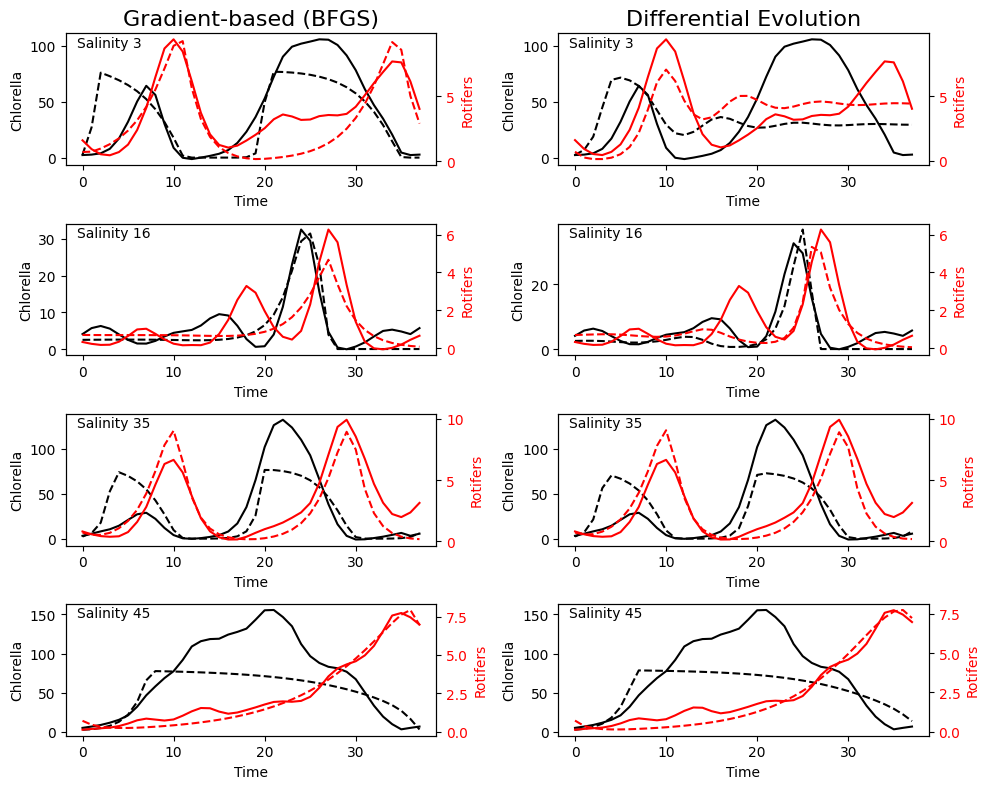

In [ ]:
fig, ax = plt.subplots(4, 2)
fig.set_size_inches([10, 8])

# We add the variation in i (not present in the initial template)
for i, salinity in enumerate(dic_dfs.keys()):

    # observed data for this salinity
    df_obs = dic_dfs[salinity]

    # population data for this salinity
    for j in range(2):

        if j == 0:

            # get simulated populations from best BFGS solution (as above)
            params = BFGS_results.loc[salinity, ["K_C", "K_R", "B_C", "B_R", "e", "m"]].values

        else:

            # get simulated populations from best DE solution (same)
            params = DE_results.loc[salinity,["K_C", "K_R", "B_C", "B_R", "e", "m"]].values

    # NB: we switched the two simulations (compared to the template) as the gradient-based one needs to be on the left according to the instructions

        # simulate model
        solution = integrate.odeint(Fussmann, y0, time, args=(params,))

        C_sim = solution[:, 1]
        R_sim = solution[:, 2]

        # Chlorella on the left y-axis
        ax[i, j].plot(time, df_obs["C"], color="black", linestyle="solid", label="Observed Chlorella")

        ax[i, j].plot(time, C_sim, color="black", linestyle="dashed", label="Modeled Chlorella")

        ax[i, j].set_ylabel("Chlorella")
        ax[i, j].set_xlabel("Time")

        # Rotifers on the right y-axis
        ax2 = ax[i, j].twinx()

        ax2.plot(time, df_obs["R"], color="red", linestyle="solid", label="Observed Rotifers")

        ax2.plot(time, R_sim, color="red", linestyle="dashed", label="Modeled Rotifers")

        ax2.set_ylabel("Rotifers", color="red")
        ax2.tick_params(axis="y", labelcolor="red")

        # set the titles
        if i == 0:
            if j == 0:
                ax[i, j].set_title("Gradient-based (BFGS)", fontsize=16)
            else:
                ax[i, j].set_title("Differential Evolution", fontsize=16)

        # Salinity label (made with ChatGPT)
        ax[i, j].text(0.03, 0.90, f"Salinity {salinity}", transform=ax[i, j].transAxes)

# Overall figure spacing
fig.tight_layout()
plt.show()

### $\color{red}{\text{Which algorithm's estimated parameters produce dynamics closer to the observations?}}$

For the last three levels of salinity, the GE and BFGS algorithms seem to be approximately equivalent in terms of fitting the observations. The gradient-based algorithm appears slightly superior in some instances, such as around 32 in the salinity = 45 diagram, but both models produce similar curve shapes.
However, for the first level of salinity (salinity = 3), the gradient-based simulation fits the data much better.
Overall, the BFGS's estimated parameters produce dynamics closer to the observations.

**Documentation of my use of Generative AI.**

I used ChatGPT to write some parts of the code, especially:
- to find the odeint function (I was a bit lost with the integrate functions and I did not know which one I had to use);
- to find how to get the parameter and obj values (I wanted to ensure that the code below - A - was right);
- to write some parts of the final visualisation (I indicated notably the part I just asked CHatGPT to write it).

I also used the natively integrated tool in Google Colab to automatically complete some bunchs of code. In particular, this tool automatically filled in a part of the BFGS algorithm - B.

In [ ]:

A

BFGS_results.loc[salinity, ["K_C", "K_R", "B_C", "B_R", "e", "m"]] = bestResult.x
BFGS_results.loc[salinity, "NSE"] = -bestResult.fun


B

# loop through initial starting points and update bestObj value and corresponding result if it improved
    for x_start in x0:
        result = minimize(ObjFunc, x0=x_start, args=(y0, time, df_obs), method="BFGS")
        if result.fun < bestObj:
            bestObj = result.fun
            bestResult = result